# 6. GPA Trajectory Analysis

Three subquestions:
1. How well does enrollment-time data predict 1st semester GPA, before any grade data exists?
2. Does adding 1st semester performance meaningfully improve 2nd semester GPA predictions?
3. Do students with a steep GPA decline between semesters show increased dropout risk?

Unlike notebooks 1-5, the target here is a continuous grade, not the 3-class outcome, so this uses regression instead of classification.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from src.evaluate import evaluate_regression_feature_set
from src.preprocessing import get_feature_availability_sets, load_data, TARGET_COL

sns.set_theme(style="whitegrid")
df = load_data()
feature_sets = get_feature_availability_sets(df)


## 6.1 A caveat that shapes everything below: structural zeros

Found during EDA (notebook 01): a meaningful share of students have a semester grade of exactly 0, not a low grade, a **zero**. This isn't "struggled academically", it's closer to "never really engaged" (only about half of these students even have zero evaluations, so it's not purely a non-participation flag, but 0 is still qualitatively different from a real grade on a continuous scale). These students overwhelmingly end up in Dropout.

In [2]:
sem1_zero = df["Curricular units 1st sem (grade)"] == 0
sem2_zero = df["Curricular units 2nd sem (grade)"] == 0

print(f"Sem1 grade = 0: {sem1_zero.sum()} students ({sem1_zero.mean():.1%})")
print(f"Sem2 grade = 0: {sem2_zero.sum()} students ({sem2_zero.mean():.1%})")
print()
print("Outcome breakdown for Sem1-zero students:")
print(df.loc[sem1_zero, TARGET_COL].value_counts(normalize=True).round(3))


Sem1 grade = 0: 718 students (16.2%)
Sem2 grade = 0: 870 students (19.7%)

Outcome breakdown for Sem1-zero students:
Target
Dropout     0.794
Graduate    0.107
Enrolled    0.099
Name: proportion, dtype: float64


**Decision:** for the regression subquestions (6.2, 6.3), fit models both on all students and on an "engaged" subset (nonzero grade in the relevant semester(s)), and compare them. Mixing a large population of true zeros into a continuous-grade regression violates the usual linear-regression assumptions and, as shown below, distorts the error metrics substantially.

In [3]:
df_engaged_sem1 = df[df["Curricular units 1st sem (grade)"] > 0]
df_engaged_both = df[(df["Curricular units 1st sem (grade)"] > 0) & (df["Curricular units 2nd sem (grade)"] > 0)]

print(f"All students: {len(df)}")
print(f"Engaged (nonzero Sem1 grade): {len(df_engaged_sem1)}")
print(f"Engaged both semesters (nonzero Sem1 AND Sem2 grade): {len(df_engaged_both)}")


All students: 4424
Engaged (nonzero Sem1 grade): 3706
Engaged both semesters (nonzero Sem1 AND Sem2 grade): 3512


## 6.2 Subquestion 1: Predicting 1st semester GPA before any grade data exists

Regression: `Curricular units 1st sem (grade)` ~ Day 1 features (demographic, admission, financial/family background, macroeconomic -- nothing from either semester).

In [4]:
sem1_results = []
for name, data in [("All students", df), ("Engaged only (nonzero Sem1 grade)", df_engaged_sem1)]:
    res = evaluate_regression_feature_set(
        data, feature_sets["Day 1"], name, LinearRegression(),
        scale_numeric=True, target_col="Curricular units 1st sem (grade)"
    )
    sem1_results.append(res)

sem1_results_df = pd.DataFrame(sem1_results)
display(sem1_results_df.round(3))


,Feature Set,R2,RMSE,MAE
0,All students,0.177,4.376,2.944
1,Engaged only (nonzero Sem1 grade),0.239,1.168,0.898


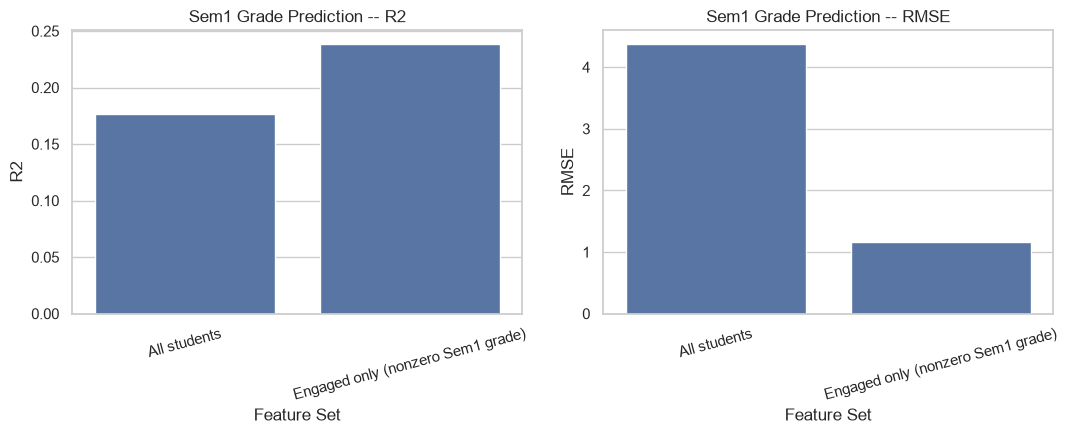

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
metrics_to_plot = ["R2", "RMSE"]
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=sem1_results_df, x="Feature Set", y=metric, ax=ax)
    ax.set_title(f"Sem1 Grade Prediction -- {metric}")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


**Answer:** yes, Day 1 information predicts 1st semester GPA better than nothing (R² around 0.2-0.24). Note how much RMSE drops once structural zeros are excluded: those few extreme outliers were dominating the error, not the model's genuine predictive signal for students who actually engaged.

## 6.3 Subquestion 2: Does 1st semester performance meaningfully improve 2nd semester GPA prediction?

Regression: `Curricular units 2nd sem (grade)` ~ Day 1 features only, vs. ~ Day 1 + 1st semester performance features (After Semester 1 set). Restricted to students engaged in both semesters, consistent with 6.1's decision, and so the same rows are compared across both feature sets.

In [6]:
sem2_results = []
for name, cols in [("Day 1 only", feature_sets["Day 1"]), ("After Semester 1", feature_sets["After Semester 1"])]:
    res = evaluate_regression_feature_set(
        df_engaged_both, cols, name, LinearRegression(),
        scale_numeric=True, target_col="Curricular units 2nd sem (grade)"
    )
    sem2_results.append(res)

sem2_results_df = pd.DataFrame(sem2_results)
display(sem2_results_df.round(3))


,Feature Set,R2,RMSE,MAE
0,Day 1 only,0.115,1.298,1.010
1,After Semester 1,0.430,1.042,0.799


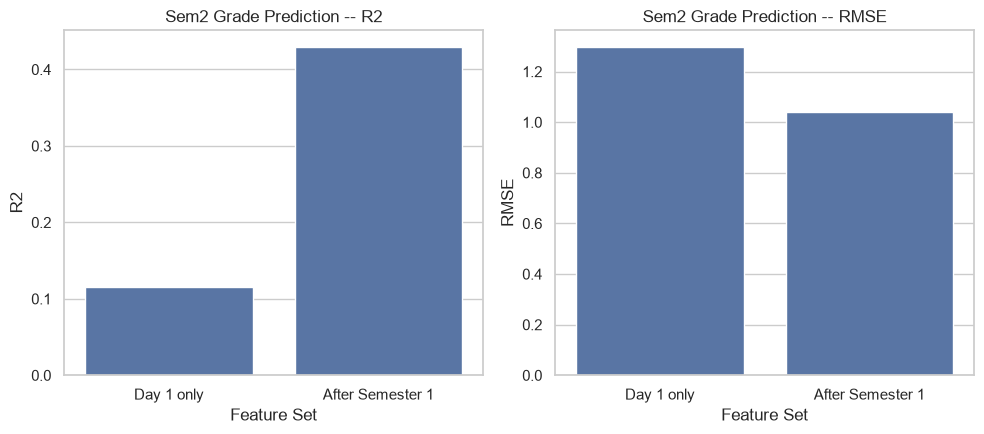

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, metric in zip(axes, ["R2", "RMSE"]):
    sns.barplot(data=sem2_results_df, x="Feature Set", y=metric, ax=ax)
    ax.set_title(f"Sem2 Grade Prediction -- {metric}")
plt.tight_layout()
plt.show()


**Answer:** yes, clearly. R² roughly quadruples once 1st semester performance is added -- academic momentum from the first semester is a much stronger predictor of 2nd semester grade than anything known at enrollment.

## 6.4 Subquestion 3: Does a steep GPA decline predict dropout risk?

Restricted to students engaged in both semesters (consistent with 6.3), since a "decline" from/to a structural zero isn't a real academic trajectory. `GPA decline = Sem1 grade - Sem2 grade` (positive = declined).

In [8]:
df_decline = df_engaged_both.copy()
df_decline["GPA decline"] = df_decline["Curricular units 1st sem (grade)"] - df_decline["Curricular units 2nd sem (grade)"]

print(df_decline["GPA decline"].describe().round(3))


count    3512.000
mean        0.004
std         1.088
min        -6.000
25%        -0.643
50%         0.000
75%         0.650
max         6.000
Name: GPA decline, dtype: float64


Target,Dropout,Enrolled,Graduate
Decline group,,,
Q1 (most improved),0.192,0.202,0.606
Q2,0.151,0.161,0.688
Q3,0.177,0.216,0.607
Q4 (steepest decline),0.249,0.244,0.507


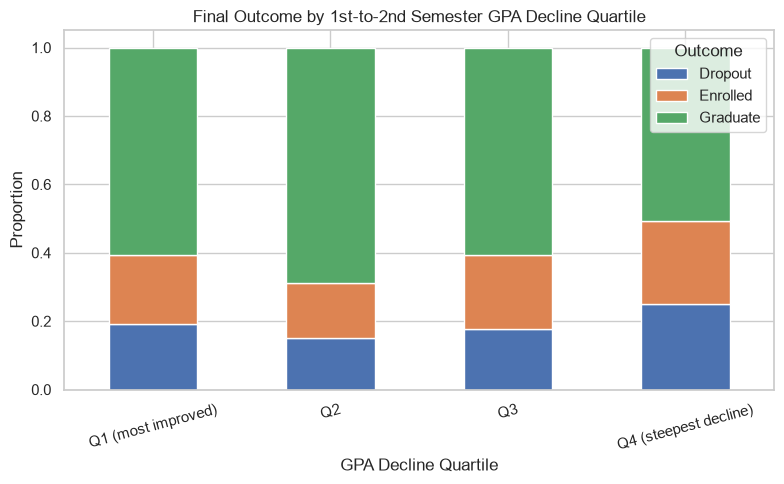

In [9]:
df_decline["Decline group"] = pd.qcut(
    df_decline["GPA decline"], q=4,
    labels=["Q1 (most improved)", "Q2", "Q3", "Q4 (steepest decline)"]
)

decline_outcomes = pd.crosstab(df_decline["Decline group"], df_decline[TARGET_COL], normalize="index")
display(decline_outcomes.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
decline_outcomes.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Final Outcome by 1st-to-2nd Semester GPA Decline Quartile")
ax.set_xlabel("GPA Decline Quartile")
ax.set_ylabel("Proportion")
plt.xticks(rotation=15)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()


In [10]:
dropout_by_quartile = decline_outcomes["Dropout"]
print("Dropout rate by decline quartile:")
print(dropout_by_quartile.round(3))
print()
print(f"Steepest-decline quartile dropout rate: {dropout_by_quartile.iloc[-1]:.1%}")
print(f"Best quartile dropout rate: {dropout_by_quartile.min():.1%}")


Dropout rate by decline quartile:
Decline group
Q1 (most improved)       0.192
Q2                       0.151
Q3                       0.177
Q4 (steepest decline)    0.249
Name: Dropout, dtype: float64

Steepest-decline quartile dropout rate: 24.9%
Best quartile dropout rate: 15.1%


**Answer:** yes, students in the steepest-decline quartile have a meaningfully higher dropout rate than students in the best-performing quartile. A sharp drop between semesters looks like a real, usable early-warning signal, not just noise.